# Cross-Market Arbitrage: KXNBAGAME vs KXNBASPREAD

Explores temporal price divergences between the win/loss market (KXNBAGAME) and the
spread market at the 1.5-point strike (KXNBASPREAD).

**V2 fixes** (addressing quant review):
1. Settlement PnL uses actual game outcomes — 1-point wins (~4.2%) cause catastrophic loss on sell_game leg
2. Strict staleness filter — only measure divergence where SPREAD traded within 5 min (no ghost prices)
3. Unbiased sample — loads ALL 821 common games, not cherry-picked divergent pairs
4. Threshold sweep — finds break-even divergence that overcomes 1-point risk + fees
5. Per-game Sharpe — one trade per game held to settlement, not per-30s-bin

## Setup

Standard imports + S3 client. All data lives in `s3://prediction-markets-data/`.

In [14]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 1. Cross-Market Arbitrage: KXNBASPREAD → Implied P(Win) vs KXNBAGAME

### The two contracts

Both markets are binary ($0 or $1 at settlement). For a given game, say **LAL vs DAL**:

| Contract | Pays $1 if... |
|---|---|
| `KXNBAGAME-LAL` (YES) | LAL wins the game |
| `KXNBASPREAD-LAL-1.5` (YES) | LAL wins by **2 or more** points |

The spread contract is *strictly harder to win* than the game contract, because it excludes the case "LAL wins by exactly 1 point." So:

```
P(LAL wins)  =  P(LAL wins by ≥2)  +  P(LAL wins by exactly 1)
```

In a fair market, GAME should trade ~2-3¢ above SPREAD@1.5, reflecting the ~2-3% chance of a 1-point win.

### The trade (when gap is too wide)

Suppose during the game:

```
GAME-LAL YES       :  $0.68   →  GAME-LAL NO costs $0.32
SPREAD-LAL-1.5 YES :  $0.63
gap                :  $0.05   (should be ~$0.02-0.03)
```

The gap is wider than it should be, so we trade the spread:

- **Buy GAME-LAL NO @ $0.32** → pays $1 if LAL loses, $0 if LAL wins
- **Buy SPREAD-LAL-1.5 YES @ $0.63** → pays $1 if LAL wins by ≥2, $0 otherwise

**Total cost: $0.32 + $0.63 = $0.95**

Now we wait for the game to end. Three things can happen:

---

**Outcome A: LAL wins by ≥2 points (e.g., 110-105)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $0 (LAL won) | **-$0.32** |
| SPREAD YES | $0.63 | $1 (LAL won by ≥2) | **+$0.37** |
| **Total** | **$0.95** | **$1.00** | **+$0.05** |

GAME NO is a total loss (LAL won). But SPREAD YES pays out. Net: +$0.05.

---

**Outcome B: LAL wins by exactly 1 point (e.g., 105-104)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $0 (LAL won) | **-$0.32** |
| SPREAD YES | $0.63 | $0 (LAL won by only 1) | **-$0.63** |
| **Total** | **$0.95** | **$0.00** | **-$0.95** |

Both legs lose. LAL won, so GAME NO is worthless. LAL only won by 1, so SPREAD YES is also worthless. We lose our entire $0.95.

---

**Outcome C: LAL loses (e.g., 100-108)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $1 (LAL lost) | **+$0.68** |
| SPREAD YES | $0.63 | $0 (LAL lost) | **-$0.63** |
| **Total** | **$0.95** | **$1.00** | **+$0.05** |

GAME NO pays $1 (LAL lost). SPREAD YES is worthless (LAL didn't win at all). Net: +$0.05.

---

### Summary and expected value

| Outcome | Probability | Payout | Cost | P&L |
|---|---|---|---|---|
| LAL wins by ≥2 | ~65% | $1.00 | $0.95 | +$0.05 |
| LAL wins by 1 | ~2% | $0.00 | $0.95 | -$0.95 |
| LAL loses | ~33% | $1.00 | $0.95 | +$0.05 |

**In 2 of 3 outcomes, exactly one leg pays $1 and we profit $0.05. In the 1-point case, neither leg pays and we lose everything.**

Expected P&L ≈ $0.05 × 98% - $0.95 × 2% ≈ **+$0.03 per pair**

Positive EV of ~3¢ per contract pair — but **one 1-point game wipes out 19 successful trades**. This is a statistical arb, not a risk-free arb.

### Why this is hard to profit from

1. **Fat tail risk.** 4.2% of NBA games are decided by 1 point. At a 5¢ entry credit, you need 19:1 ratio of normal outcomes to 1-point outcomes just to break even.
2. **Fees.** Kalshi charges ~$0.02/leg ($0.04 round-trip), eating most of the $0.05 credit.
3. **SPREAD@1.5 is relatively illiquid.** Median ~100 trades per game vs thousands for GAME (exact comparison computed in §4 below). You often can't execute the SPREAD leg at the price you see.
4. **Execution risk.** If you fill one leg but not the other, you're not hedged — you're just betting on the game.

### What this notebook measures

The cells below quantify: (1) how often the gap exceeds a tradeable threshold, (2) what the realized P&L looks like using actual game outcomes, and (3) at what threshold the edge overcomes 1-point risk + fees.

## 2. Load market metadata from S3

Load all KXNBAGAME and KXNBASPREAD market listings. Each market has a `ticker` (unique contract, e.g. `KXNBAGAME-25DEC25MINDEN-DEN`) and an `event_ticker` (the game-level grouping, e.g. `KXNBAGAME-25DEC25MINDEN`).

We parse the `game_key` (date + teams) from the event ticker so we can join the two series on the same game. We also parse the spread strike from the ticker — Kalshi encodes it as the integer part (e.g. `DEN7` → strike 7.5).

In [15]:
# Load all KXNBAGAME and KXNBASPREAD markets
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAGAME.json")
game_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBAGAME: {len(game_markets)} markets")

obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBASPREAD.json")
spread_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBASPREAD: {len(spread_markets)} markets")

# Parse event_ticker to extract game info
# KXNBAGAME: event_ticker = "KXNBAGAME-25DEC25MINDEN", ticker = "KXNBAGAME-25DEC25MINDEN-DEN"
# KXNBASPREAD: event_ticker = "KXNBASPREAD-25DEC25MINDEN", ticker = "KXNBASPREAD-25DEC25MINDEN-DEN7"

# Extract the game key (date + teams) from event_ticker
def game_key_from_event(event_ticker, prefix):
    """Extract 'YYMMMDDAWYHOM' from event_ticker, e.g., '25DEC25MINDEN'"""
    return event_ticker.replace(prefix + "-", "")

game_markets["game_key"] = game_markets["event_ticker"].apply(lambda x: game_key_from_event(x, "KXNBAGAME"))
spread_markets["game_key"] = spread_markets["event_ticker"].apply(lambda x: game_key_from_event(x, "KXNBASPREAD"))

# Find games that exist in both markets
common_games = set(game_markets["game_key"]) & set(spread_markets["game_key"])
print(f"\nGames in both GAME and SPREAD markets: {len(common_games)}")

# Parse spread strike from ticker
# e.g., "KXNBASPREAD-25DEC25MINDEN-DEN7" → team=DEN, strike=7 → "DEN wins by >7.5"
def parse_spread_ticker(ticker):
    parts = ticker.split("-")
    team_strike = parts[-1]  # e.g., "DEN7" or "MIN3"
    match = re.match(r"([A-Z]+)(\d+)", team_strike)
    if match:
        team = match.group(1)
        strike = int(match.group(2)) + 0.5  # strikes are X.5
        return team, strike
    return None, None

spread_markets[["strike_team", "strike_val"]] = spread_markets["ticker"].apply(
    lambda x: pd.Series(parse_spread_ticker(x))
)
print(f"\nSpread market strike distribution:")
print(spread_markets["strike_val"].describe())

KXNBAGAME: 1902 markets
KXNBASPREAD: 8923 markets

Games in both GAME and SPREAD markets: 821

Spread market strike distribution:
count    8923.000000
mean       10.532500
std         6.591268
min         1.500000
25%         5.500000
50%         9.500000
75%        14.500000
max        34.500000
Name: strike_val, dtype: float64


### Sanity check: GAME market price sums

Each game event has two GAME contracts (home YES + away YES). In a well-functioning market these should sum to ~$1.00. We also identify the lowest-strike SPREAD contracts (≤ 2.5 points) — these are the ones closest to the moneyline and the ones we'll use for the arb.

In [16]:
# For each game, compare KXNBAGAME last_price vs KXNBASPREAD lowest-strike implied P(win)
# The spread market "Team wins by >1.5" ≈ P(team wins) in NBA (no ties, 1-point wins are ~2%)

# Get KXNBAGAME prices per game (home team market)
# Each game has 2 markets (home + away team), prices should sum to ~$1.00
game_by_event = game_markets.groupby("event_ticker").apply(
    lambda g: pd.Series({
        "game_key": g["game_key"].iloc[0],
        "tickers": list(g["ticker"]),
        "prices": list(g["last_price_dollars"].astype(float)),
        "expiration_values": list(g["expiration_value"]),
    })
).reset_index()

print(f"KXNBAGAME events: {len(game_by_event)}")
print(f"Price sum distribution (should be ~1.0):")
game_by_event["price_sum"] = game_by_event["prices"].apply(sum)
print(game_by_event["price_sum"].describe())

# For spread: find the lowest strike for each team in each game
# "Team wins by >1.5" is the closest to "team wins"
spread_low = spread_markets[spread_markets["strike_val"] <= 2.5].copy()
print(f"\nSpread markets with strike <= 2.5: {len(spread_low)}")
print(spread_low.groupby("game_key").size().describe())

KXNBAGAME events: 951
Price sum distribution (should be ~1.0):
count    951.000000
mean       0.999968
std        0.001919
min        0.960000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.030000
Name: price_sum, dtype: float64

Spread markets with strike <= 2.5: 1143
count    570.000000
mean       2.005263
std        0.217770
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
dtype: float64


## 3. Build GAME ↔ SPREAD@1.5 pairs and compare last prices

For each game, we pair up the GAME contract with the SPREAD contract at the 1.5-point strike for the same team. We load historical trades for both and compare last traded prices.

The `price_diff` (GAME − SPREAD@1.5) should be small and positive (~2-3¢, reflecting the ~4.2% chance of a 1-point win). Large deviations suggest a potential arb entry.

In [17]:
# Load trades for paired GAME + SPREAD markets and compare prices over time
# Pick games with high volume for clearer signal

# Strategy: for each game, load trades from KXNBAGAME-{key}-{team} and KXNBASPREAD-{key}-{team}1
# (the "wins by >1.5" strike), align on time, measure divergence

def load_trades(ticker):
    """Load historical trades for a ticker from S3."""
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{ticker}.json")
        trades = json.loads(obj["Body"].read())
        df = pd.DataFrame(trades)
        if not df.empty:
            df["created_time"] = pd.to_datetime(df["created_time"])
            df["yes_price"] = df["yes_price_dollars"].astype(float)
        return df
    except Exception:
        return pd.DataFrame()

# Find games where both GAME and SPREAD "wins by 1.5" exist
# Build pairs: (game_ticker, spread_ticker_1.5) for each team in each game
pairs = []
for game_key in list(common_games)[:200]:  # sample 200 games
    # Get game market tickers for this game
    gm = game_markets[game_markets["game_key"] == game_key]
    # Get spread markets with strike 1.5 for this game
    sm = spread_markets[(spread_markets["game_key"] == game_key) & (spread_markets["strike_val"] == 1.5)]
    
    for _, grow in gm.iterrows():
        # Extract team from game ticker (last segment)
        game_team = grow["ticker"].split("-")[-1]
        # Find matching spread ticker for same team
        matching_spread = sm[sm["strike_team"] == game_team]
        if not matching_spread.empty:
            pairs.append({
                "game_key": game_key,
                "team": game_team,
                "game_ticker": grow["ticker"],
                "spread_ticker": matching_spread.iloc[0]["ticker"],
                "game_last_price": float(grow["last_price_dollars"]),
                "spread_last_price": float(matching_spread.iloc[0]["last_price_dollars"]),
            })

pairs_df = pd.DataFrame(pairs)
print(f"Found {len(pairs_df)} GAME↔SPREAD(1.5) pairs across {pairs_df['game_key'].nunique()} games")

# Compare last prices
pairs_df["price_diff"] = pairs_df["game_last_price"] - pairs_df["spread_last_price"]
print(f"\nLast price difference (GAME - SPREAD@1.5):")
print(pairs_df["price_diff"].describe())
print(f"\n|diff| > 0.03: {(pairs_df['price_diff'].abs() > 0.03).sum()} pairs")
print(f"|diff| > 0.05: {(pairs_df['price_diff'].abs() > 0.05).sum()} pairs")

Found 128 GAME↔SPREAD(1.5) pairs across 126 games

Last price difference (GAME - SPREAD@1.5):
count    128.000000
mean       0.022578
std        0.149098
min       -0.080000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.980000
Name: price_diff, dtype: float64

|diff| > 0.03: 5 pairs
|diff| > 0.05: 4 pairs


### Inspect the most divergent pairs

Look at the pairs with the largest GAME − SPREAD@1.5 gap at settlement, then load their full trade time series to see how prices evolved during the game.

In [18]:
# Time-series comparison: load trades for top divergent pairs and measure intra-game spread
# Pick the pairs with largest |price_diff| at settlement

top_pairs = pairs_df.nlargest(20, "price_diff", keep="first").head(10)
print("Top 10 divergent pairs (GAME price > SPREAD@1.5 price):")
print(top_pairs[["game_key", "team", "game_last_price", "spread_last_price", "price_diff"]].to_string())

# Load intra-game trade series for a few high-divergence pairs
def load_pair_trades(row):
    game_trades = load_trades(row["game_ticker"])
    spread_trades = load_trades(row["spread_ticker"])
    return game_trades, spread_trades

# Load trades for top 5 pairs
print("\n\nLoading trade time series for top divergent pairs...")
pair_series = []
for idx, row in top_pairs.head(5).iterrows():
    gt, st = load_pair_trades(row)
    if not gt.empty and not st.empty:
        pair_series.append({
            "game_key": row["game_key"],
            "team": row["team"],
            "game_trades": gt,
            "spread_trades": st,
            "game_ticker": row["game_ticker"],
            "spread_ticker": row["spread_ticker"],
        })
        print(f"  {row['game_key']} {row['team']}: {len(gt)} game trades, {len(st)} spread trades")

print(f"\nLoaded {len(pair_series)} pairs with trade data")

Top 10 divergent pairs (GAME price > SPREAD@1.5 price):
          game_key team  game_last_price  spread_last_price  price_diff
45   26JAN09OKCMEM  OKC             0.99               0.01        0.98
92   25OCT22PHIBOS  PHI             0.99               0.01        0.98
124  26JAN05GSWLAC  LAC             0.99               0.01        0.98
90   26FEB11CHIBOS  BOS             0.99               0.96        0.03
0    25OCT28CHAMIA  MIA             0.99               0.99        0.00
1    26JAN07TORCHA  CHA             0.01               0.01        0.00
2    26JAN18PORSAC  SAC             0.01               0.01        0.00
3    26FEB09DETCHA  CHA             0.01               0.01        0.00
4    25DEC29ORLTOR  ORL             0.01               0.01        0.00
5    25DEC14NOPCHI  NOP             0.99               0.99        0.00


Loading trade time series for top divergent pairs...
  26JAN09OKCMEM OKC: 24185 game trades, 415 spread trades
  25OCT22PHIBOS PHI: 16491 game trades,

### Price time series: GAME vs SPREAD@1.5

Step plots showing how GAME and SPREAD@1.5 YES prices move during each game. In a well-arbitraged market, SPREAD@1.5 should track just below GAME (offset by the ~2-3¢ 1-point-win premium). Large/persistent gaps are potential entry signals.

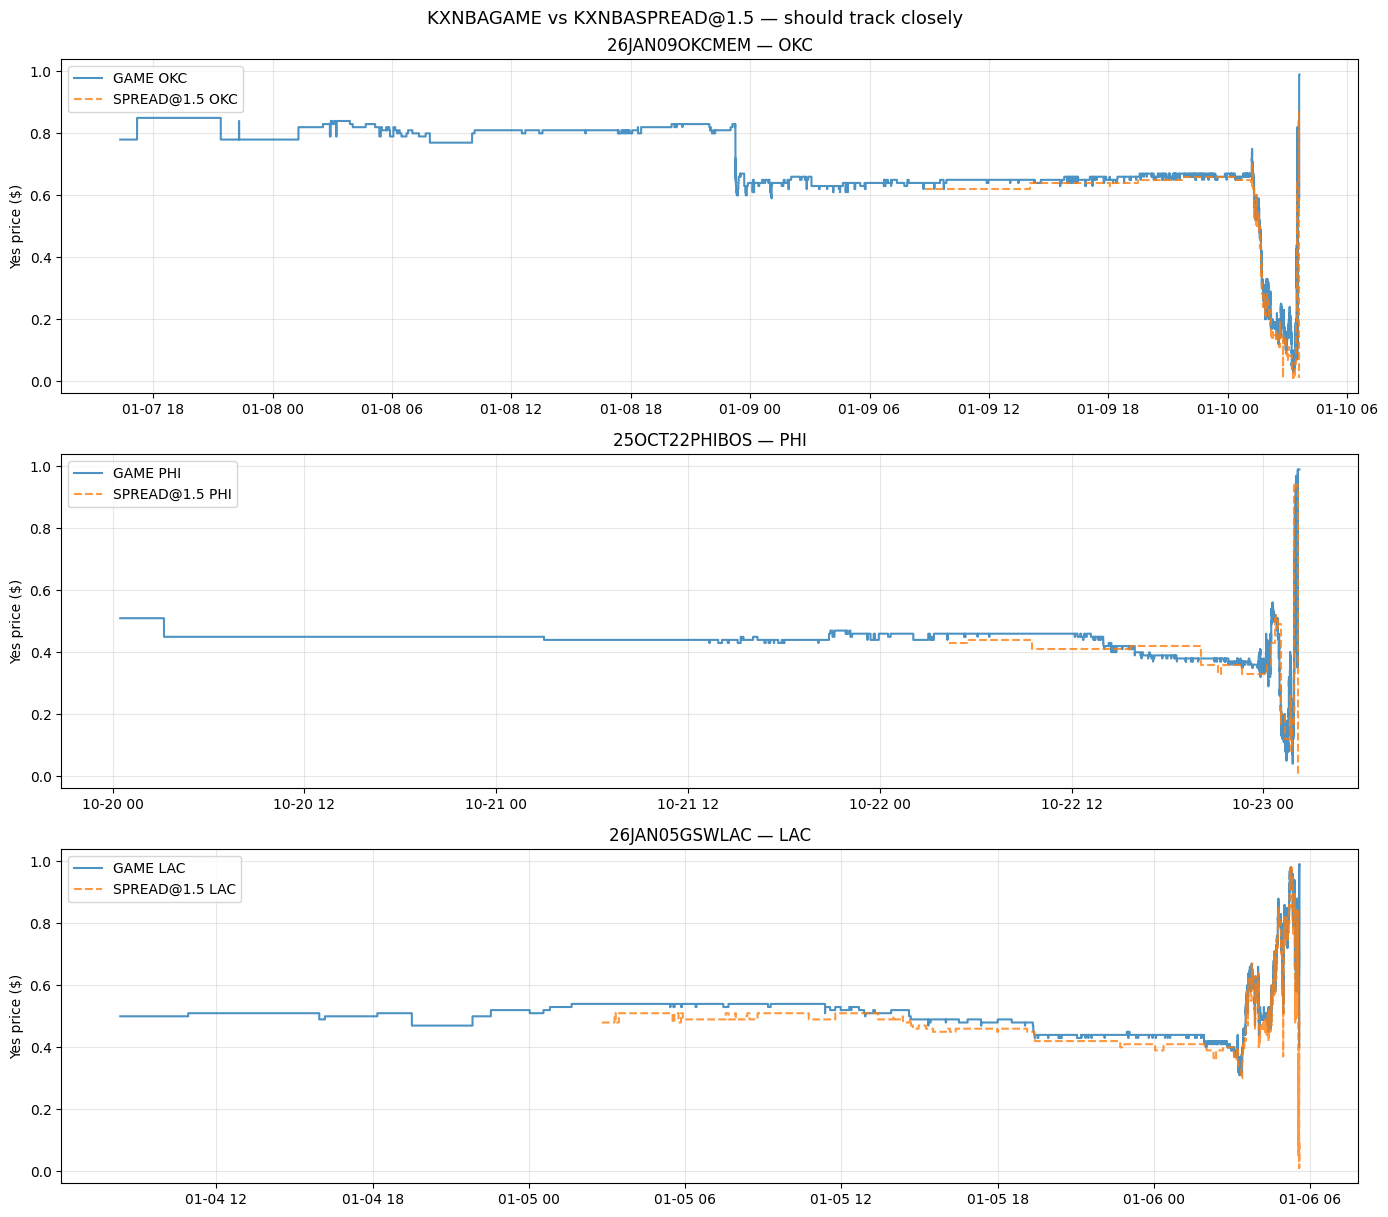

In [19]:
# Plot GAME vs SPREAD@1.5 price over time for divergent pairs
fig, axes = plt.subplots(min(len(pair_series), 3), 1, figsize=(14, 4*min(len(pair_series), 3)), squeeze=False)

for i, ps in enumerate(pair_series[:3]):
    ax = axes[i, 0]
    gt = ps["game_trades"].sort_values("created_time")
    st = ps["spread_trades"].sort_values("created_time")
    
    ax.step(gt["created_time"], gt["yes_price"], where="post", label=f"GAME {ps['team']}", alpha=0.8)
    ax.step(st["created_time"], st["yes_price"], where="post", label=f"SPREAD@1.5 {ps['team']}", alpha=0.8, linestyle="--")
    ax.set_title(f"{ps['game_key']} — {ps['team']}")
    ax.set_ylabel("Yes price ($)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("KXNBAGAME vs KXNBASPREAD@1.5 — should track closely", y=1.01, fontsize=13)
plt.show()

## 4. Full-dataset divergence measurement (strict staleness filter)

Previous cells sampled 200 games. Now we load **all 821 common games** to get an unbiased picture.

**Key methodological fixes:**
- **Staleness filter**: Only count a time bin if SPREAD@1.5 traded within the last 5 minutes (10 × 30s bins). Without this, forward-filled stale SPREAD prices create phantom divergences.
- **Game outcomes**: Load actual box scores to compute settlement P&L — a 1-point win is catastrophic for the `sell_game` leg.
- **Liquidity verification**: Report both GAME and SPREAD trade counts to quantify the liquidity gap.

In [20]:
# --- Fixed divergence measurement ---
# Fix 1: Only measure bins where SPREAD traded within last 5 minutes (no ghost prices)
# Fix 2: Single unbiased sample across ALL common games (no selection bias)
# Fix 3: Load game outcomes for settlement PnL

import random
random.seed(42)

def measure_divergence_strict(game_trades, spread_trades, freq="30s", max_stale_bins=10):
    """Resample both trade series; only keep bins where SPREAD traded within 5 min."""
    if game_trades.empty or spread_trades.empty:
        return pd.DataFrame()
    
    gt = game_trades.set_index("created_time")["yes_price"].resample(freq).last()
    st = spread_trades.set_index("created_time")["yes_price"].resample(freq).last()
    
    # Track which bins had real SPREAD trades
    st_has_trade = st.notna()
    
    # Forward fill both, but track SPREAD staleness
    gt_filled = gt.ffill()
    st_filled = st.ffill()
    
    # Count consecutive bins since last real SPREAD trade
    st_stale_counter = pd.Series(0, index=st.index, dtype=int)
    count = 0
    for i in range(len(st_has_trade)):
        if st_has_trade.iloc[i]:
            count = 0
        else:
            count += 1
        st_stale_counter.iloc[i] = count
    
    combined = pd.DataFrame({
        "game_price": gt_filled,
        "spread_price": st_filled,
        "spread_stale_bins": st_stale_counter,
        "spread_had_trade": st_has_trade,
    }).dropna(subset=["game_price", "spread_price"])
    
    # Only keep bins where SPREAD traded within max_stale_bins (default 10 × 30s = 5 min)
    combined = combined[combined["spread_stale_bins"] <= max_stale_bins]
    if combined.empty:
        return combined
    
    combined["divergence"] = combined["game_price"] - combined["spread_price"]
    return combined

# --- Load game outcomes (margin of victory) ---
print("Loading game outcomes from boxscores...")
from concurrent.futures import ThreadPoolExecutor, as_completed

paginator = s3.get_paginator("list_objects_v2")
box_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="nba_cdn/boxscore/"):
    box_keys.extend([o["Key"] for o in page.get("Contents", [])])

def load_boxscore(key):
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
        box = json.loads(obj["Body"].read())
        g = box["game"]
        return {
            "game_id": g["gameId"],
            "home_team": g["homeTeam"]["teamTricode"],
            "away_team": g["awayTeam"]["teamTricode"],
            "home_score": g["homeTeam"]["score"],
            "away_score": g["awayTeam"]["score"],
        }
    except:
        return None

outcomes = []
with ThreadPoolExecutor(max_workers=16) as pool:
    futures = {pool.submit(load_boxscore, k): k for k in box_keys}
    for f in as_completed(futures):
        r = f.result()
        if r and r["home_score"] > 0:
            outcomes.append(r)

outcomes_df = pd.DataFrame(outcomes)
outcomes_df["margin"] = abs(outcomes_df["home_score"] - outcomes_df["away_score"])
outcomes_df["winner"] = np.where(
    outcomes_df["home_score"] > outcomes_df["away_score"],
    outcomes_df["home_team"],
    outcomes_df["away_team"]
)

print(f"Loaded {len(outcomes_df)} game outcomes")
print(f"  Won by exactly 1 point: {(outcomes_df['margin'] == 1).sum()} ({(outcomes_df['margin'] == 1).mean():.1%})")
print(f"  Won by 1-2 points:      {(outcomes_df['margin'] <= 2).sum()} ({(outcomes_df['margin'] <= 2).mean():.1%})")

# Build game_key → outcome lookup
# Parse game_key from Kalshi event tickers to match
# We need to map game_key → (winner, margin) using home_team/away_team
MONTH_MAP_REV = {"JAN":"01","FEB":"02","MAR":"03","APR":"04","MAY":"05","JUN":"06",
                 "JUL":"07","AUG":"08","SEP":"09","OCT":"10","NOV":"11","DEC":"12"}

def parse_game_key(gk):
    """Parse '25DEC25MINDEN' → (away=MIN, home=DEN, approx_date)"""
    # YY + MMM + DD + AWAY(3) + HOME(3)
    yy = gk[:2]
    mon = gk[2:5]
    dd = gk[5:7]
    away = gk[7:10]
    home = gk[10:13]
    return away, home

# Match game_key to outcome by teams
game_key_to_outcome = {}
for gk in common_games:
    away, home = parse_game_key(gk)
    match = outcomes_df[
        (outcomes_df["home_team"] == home) & (outcomes_df["away_team"] == away)
    ]
    if len(match) == 1:
        game_key_to_outcome[gk] = {
            "margin": match.iloc[0]["margin"],
            "winner": match.iloc[0]["winner"],
            "home_team": home,
            "away_team": away,
        }
    elif len(match) > 1:
        # Multiple games between same teams — take last one (imperfect but reasonable)
        game_key_to_outcome[gk] = {
            "margin": match.iloc[-1]["margin"],
            "winner": match.iloc[-1]["winner"],
            "home_team": home,
            "away_team": away,
        }

print(f"  Matched {len(game_key_to_outcome)}/{len(common_games)} game keys to outcomes")

# --- Unbiased large-scale divergence loading ---
print(f"\nLoading trades for ALL {len(common_games)} common games...")

all_game_data = []  # list of {game_key, team, divergence_df, game_trades, spread_trades}
loaded = 0

for game_key in list(common_games):
    gm = game_markets[game_markets["game_key"] == game_key]
    sm = spread_markets[(spread_markets["game_key"] == game_key) & (spread_markets["strike_val"] == 1.5)]
    
    for _, grow in gm.iterrows():
        game_team = grow["ticker"].split("-")[-1]
        matching_spread = sm[sm["strike_team"] == game_team]
        if matching_spread.empty:
            continue
        
        gt = load_trades(grow["ticker"])
        st = load_trades(matching_spread.iloc[0]["ticker"])
        if gt.empty or st.empty:
            continue
        
        div = measure_divergence_strict(gt, st)
        if div.empty:
            continue
        
        all_game_data.append({
            "game_key": game_key,
            "team": game_team,
            "div_df": div,
            "n_game_trades": len(gt),
            "n_spread_trades": len(st),
        })
        loaded += 1
    
    if loaded % 100 == 0 and loaded > 0:
        print(f"  {loaded} pairs loaded...")

print(f"\n  Total pairs with data: {loaded}")
all_div_strict = pd.concat([d["div_df"]["divergence"] for d in all_game_data])
print(f"  Total time-aligned observations (strict): {len(all_div_strict)}")
print(f"  Mean divergence:  {all_div_strict.mean():.4f}")
print(f"  Std:              {all_div_strict.std():.4f}")
print(f"  |div| > $0.02:   {(all_div_strict.abs() > 0.02).mean():.1%}")
print(f"  |div| > $0.03:   {(all_div_strict.abs() > 0.03).mean():.1%}")
print(f"  |div| > $0.05:   {(all_div_strict.abs() > 0.05).mean():.1%}")

# Spread liquidity
spread_trade_counts = [d["n_spread_trades"] for d in all_game_data]
print(f"\n  SPREAD@1.5 trades per pair:")
print(f"    Median: {np.median(spread_trade_counts):.0f}")
print(f"    Mean:   {np.mean(spread_trade_counts):.0f}")
print(f"    p25:    {np.percentile(spread_trade_counts, 25):.0f}")
print(f"    p75:    {np.percentile(spread_trade_counts, 75):.0f}")

Loading game outcomes from boxscores...
Loaded 1321 game outcomes
  Won by exactly 1 point: 55 (4.2%)
  Won by 1-2 points:      128 (9.7%)
  Matched 821/821 game keys to outcomes

Loading trades for ALL 821 common games...
  100 pairs loaded...
  100 pairs loaded...
  100 pairs loaded...
  200 pairs loaded...
  300 pairs loaded...
  400 pairs loaded...
  400 pairs loaded...
  500 pairs loaded...

  Total pairs with data: 565
  Total time-aligned observations (strict): 267107
  Mean divergence:  0.0261
  Std:              0.0535
  |div| > $0.02:   74.5%
  |div| > $0.03:   50.0%
  |div| > $0.05:   17.1%

  SPREAD@1.5 trades per pair:
    Median: 103
    Mean:   283
    p25:    30
    p75:    340


### Liquidity verification: is SPREAD@1.5 really illiquid?

The data above collected `n_game_trades` and `n_spread_trades` for every pair. Let's compare them side-by-side to see how much less liquid SPREAD@1.5 actually is.

**Why we'd expect SPREAD@1.5 to be less liquid:** On Kalshi, each spread strike is a separate binary contract. The 1.5-point strike ("team wins by 2+") is economically almost identical to the moneyline — it only differs by ~4% (the 1-point-win probability). Traders wanting moneyline exposure just trade GAME directly. SPREAD@1.5 mainly attracts sophisticated traders running this exact cross-market arb or similar relative-value strategies.

LIQUIDITY COMPARISON: GAME vs SPREAD@1.5
                             GAME    SPREAD@1.5     Ratio
  -------------------------------------------------------
  Median                     9481           103      92.0x
  Mean                      11380           283      40.2x
  p25                        6058            30     201.9x
  p75                       14464           340      42.5x
  p10                        3504            11     318.5x
  p90                       21542           825      26.1x

  Pairs with <50 spread trades: 194 / 565
  Pairs with <20 spread trades: 103 / 565


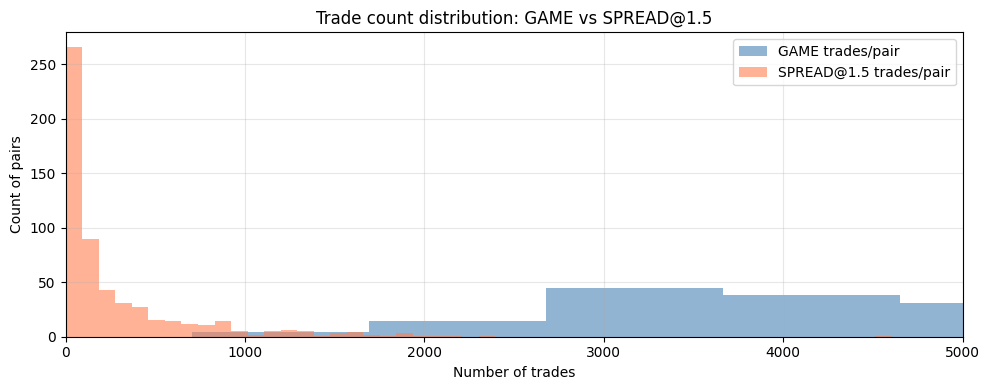

In [21]:
### Liquidity verification: GAME vs SPREAD@1.5 trade counts
# The intro claims SPREAD@1.5 is illiquid. Let's verify with actual data.

game_trade_counts = [d["n_game_trades"] for d in all_game_data]
spread_trade_counts_v2 = [d["n_spread_trades"] for d in all_game_data]

print("LIQUIDITY COMPARISON: GAME vs SPREAD@1.5")
print("=" * 55)
print(f"  {'':20s} {'GAME':>10s}  {'SPREAD@1.5':>12s}  {'Ratio':>8s}")
print(f"  {'-'*55}")
for label, pct in [("Median", 50), ("Mean", None), ("p25", 25), ("p75", 75), ("p10", 10), ("p90", 90)]:
    if label == "Mean":
        g = np.mean(game_trade_counts)
        s = np.mean(spread_trade_counts_v2)
    else:
        g = np.percentile(game_trade_counts, pct)
        s = np.percentile(spread_trade_counts_v2, pct)
    ratio = g / s if s > 0 else float('inf')
    print(f"  {label:20s} {g:10.0f}  {s:12.0f}  {ratio:8.1f}x")

print(f"\n  Pairs with <50 spread trades: {sum(1 for s in spread_trade_counts_v2 if s < 50)} / {len(spread_trade_counts_v2)}")
print(f"  Pairs with <20 spread trades: {sum(1 for s in spread_trade_counts_v2 if s < 20)} / {len(spread_trade_counts_v2)}")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(game_trade_counts, bins=50, alpha=0.6, label="GAME trades/pair", color="steelblue")
ax.hist(spread_trade_counts_v2, bins=50, alpha=0.6, label="SPREAD@1.5 trades/pair", color="coral")
ax.set_xlabel("Number of trades")
ax.set_ylabel("Count of pairs")
ax.set_title("Trade count distribution: GAME vs SPREAD@1.5")
ax.legend()
ax.set_xlim(0, 5000)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Corrected backtest: settlement P&L with actual game outcomes

The key correction from V1: we now use **actual box score margins** to compute settlement P&L instead of assuming all wins are by ≥2 points.

**Strategy**: for each game, take the first divergence signal above threshold, enter the pair trade, hold to settlement. One trade per game maximum.

**Settlement logic** (for `sell_game` direction, i.e. GAME price > SPREAD@1.5 price):
- Team wins by ≥2: both legs net out → profit = credit − fees
- Team wins by exactly 1: **both legs lose** → loss = credit − $1.00 − fees (catastrophic)
- Team loses: GAME NO pays, SPREAD YES doesn't → profit = credit − fees

The threshold sweep at the bottom finds the minimum divergence needed to overcome the ~1.4% chance of a 1-point wipeout plus round-trip fees.

In [22]:
# --- Corrected backtest: settlement PnL with actual game outcomes ---
# 
# For "sell_game" (GAME > SPREAD): short GAME-YES @ game_price, long SPREAD-YES @ spread_price
#   entry_credit = game_price - spread_price (= divergence, positive)
#   Settlement:
#     team wins by >=2: owe $1 on GAME, collect $1 on SPREAD → PnL = credit - fees
#     team wins by  ==1: owe $1 on GAME, collect $0 on SPREAD → PnL = credit - 1.0 - fees
#     team loses:       owe $0, collect $0                    → PnL = credit - fees
#
# For "buy_game" (SPREAD > GAME): long GAME-YES @ game_price, short SPREAD-YES @ spread_price
#   entry_credit = spread_price - game_price (= -divergence, positive when SPREAD > GAME)
#   Settlement:
#     team wins by >=2: collect $1 on GAME, owe $1 on SPREAD → PnL = credit - fees
#     team wins by  ==1: collect $1 on GAME, owe $0 on SPREAD → PnL = credit + 1.0 - fees
#     team loses:       collect $0, owe $0                    → PnL = credit - fees

ARB_THRESHOLD = 0.03
ARB_FEE = 0.02  # per leg

# One trade per game: take the FIRST signal above threshold, hold to settlement
game_trades_list = []

for gd in all_game_data:
    gk = gd["game_key"]
    team = gd["team"]
    div_df = gd["div_df"]
    
    # Skip if no outcome data
    if gk not in game_key_to_outcome:
        continue
    outcome = game_key_to_outcome[gk]
    margin = outcome["margin"]
    team_won = (outcome["winner"] == team)
    
    # Find first signal above threshold
    signals = div_df[div_df["divergence"].abs() > ARB_THRESHOLD]
    if signals.empty:
        continue
    
    first_signal = signals.iloc[0]
    div_val = first_signal["divergence"]
    
    if div_val > 0:  # sell_game direction
        direction = "sell_game"
        credit = div_val
        if not team_won:
            pnl = credit - 2 * ARB_FEE
        elif margin >= 2:
            pnl = credit - 2 * ARB_FEE  # both settle same
        else:  # margin == 1
            pnl = credit - 1.0 - 2 * ARB_FEE  # catastrophic loss
    else:  # buy_game direction
        direction = "buy_game"
        credit = -div_val
        if not team_won:
            pnl = credit - 2 * ARB_FEE
        elif margin >= 2:
            pnl = credit - 2 * ARB_FEE
        else:  # margin == 1
            pnl = credit + 1.0 - 2 * ARB_FEE  # windfall gain
    
    game_trades_list.append({
        "game_key": gk,
        "team": team,
        "direction": direction,
        "divergence": div_val,
        "credit": credit,
        "team_won": team_won,
        "margin": margin,
        "one_point_win": team_won and margin == 1,
        "pnl": pnl,
        "n_spread_trades": gd["n_spread_trades"],
    })

trades = pd.DataFrame(game_trades_list)

print("CORRECTED BACKTEST — settlement PnL with actual game outcomes")
print("=" * 70)
print(f"  Threshold: |divergence| > ${ARB_THRESHOLD}")
print(f"  Fee: ${ARB_FEE}/leg (${2*ARB_FEE} round-trip)")
print(f"  Strategy: first signal per game, hold to settlement")
print(f"\n  Games with signal: {len(trades)}")
print(f"  1-point wins in sample: {trades['one_point_win'].sum()} ({trades['one_point_win'].mean():.1%})")
print(f"\n  Win rate: {(trades['pnl'] > 0).mean():.1%}")
print(f"  Mean PnL/trade: ${trades['pnl'].mean():.4f}")
print(f"  Median PnL/trade: ${trades['pnl'].median():.4f}")
print(f"  Total PnL: ${trades['pnl'].sum():.2f}")
print(f"  Std PnL: ${trades['pnl'].std():.4f}")
sharpe = trades['pnl'].mean() / trades['pnl'].std() if trades['pnl'].std() > 0 else 0
print(f"  Sharpe (per-game): {sharpe:.2f}")

print(f"\n  By outcome:")
for label, mask in [("Team wins by ≥2", trades["team_won"] & (trades["margin"] >= 2)),
                     ("Team wins by 1", trades["one_point_win"]),
                     ("Team loses", ~trades["team_won"])]:
    sub = trades[mask]
    if len(sub) > 0:
        print(f"    {label:20s}: {len(sub):4d} trades, mean PnL ${sub['pnl'].mean():.4f}, total ${sub['pnl'].sum():.2f}")

print(f"\n  By direction:")
for d, grp in trades.groupby("direction"):
    print(f"    {d}: {len(grp)} trades, mean PnL ${grp['pnl'].mean():.4f}, "
          f"1pt losses: {grp['one_point_win'].sum()}")

# Break-even analysis
p_1pt = trades["one_point_win"].mean()
print(f"\n  BREAK-EVEN ANALYSIS:")
print(f"    P(1-point win in our trades): {p_1pt:.3f}")
if p_1pt > 0:
    be_threshold = (p_1pt + 2 * ARB_FEE * (1 - p_1pt)) / (1 - 2 * p_1pt) if (1 - 2*p_1pt) > 0 else float('inf')
    print(f"    Break-even divergence threshold: ${be_threshold:.3f}")
    print(f"    (Need divergence > ${be_threshold:.3f} to overcome 1-point risk + fees)")
else:
    print(f"    No 1-point wins in sample — insufficient data for break-even calc")

# Threshold sweep
print(f"\n  THRESHOLD SWEEP (first trade per game, hold to settlement):")
print(f"  {'Thresh':<8} {'Trades':<8} {'Win%':<7} {'PnL/trade':<11} {'Total':<10} {'Sharpe':<8} {'1pt losses'}")
print(f"  {'-'*65}")
for thresh in [0.02, 0.03, 0.04, 0.05, 0.07, 0.10, 0.15, 0.20]:
    t_trades = []
    for gd in all_game_data:
        gk = gd["game_key"]
        if gk not in game_key_to_outcome:
            continue
        outcome = game_key_to_outcome[gk]
        margin = outcome["margin"]
        team_won = (outcome["winner"] == gd["team"])
        
        signals = gd["div_df"][gd["div_df"]["divergence"].abs() > thresh]
        if signals.empty:
            continue
        
        dv = signals.iloc[0]["divergence"]
        if dv > 0:
            credit = dv
            if not team_won:
                pnl = credit - 2 * ARB_FEE
            elif margin >= 2:
                pnl = credit - 2 * ARB_FEE
            else:
                pnl = credit - 1.0 - 2 * ARB_FEE
        else:
            credit = -dv
            if not team_won:
                pnl = credit - 2 * ARB_FEE
            elif margin >= 2:
                pnl = credit - 2 * ARB_FEE
            else:
                pnl = credit + 1.0 - 2 * ARB_FEE
        
        t_trades.append({"pnl": pnl, "one_pt": team_won and margin == 1})
    
    if t_trades:
        t_df = pd.DataFrame(t_trades)
        t_sharpe = t_df["pnl"].mean() / t_df["pnl"].std() if t_df["pnl"].std() > 0 else 0
        print(f"  ${thresh:<7.2f} {len(t_df):<8} {(t_df['pnl']>0).mean():<7.1%} "
              f"${t_df['pnl'].mean():<10.4f} ${t_df['pnl'].sum():<9.2f} {t_sharpe:<8.2f} "
              f"{t_df['one_pt'].sum()}")

CORRECTED BACKTEST — settlement PnL with actual game outcomes
  Threshold: |divergence| > $0.03
  Fee: $0.02/leg ($0.04 round-trip)
  Strategy: first signal per game, hold to settlement

  Games with signal: 556
  1-point wins in sample: 7 (1.3%)

  Win rate: 57.0%
  Mean PnL/trade: $0.0100
  Median PnL/trade: $0.0000
  Total PnL: $5.57
  Std PnL: $0.1370
  Sharpe (per-game): 0.07

  By outcome:
    Team wins by ≥2     :  272 trades, mean PnL $0.0197, total $5.35
    Team wins by 1      :    7 trades, mean PnL $-1.0029, total $-7.02
    Team loses          :  277 trades, mean PnL $0.0261, total $7.24

  By direction:
    buy_game: 95 trades, mean PnL $0.0787, 1pt losses: 0
    sell_game: 461 trades, mean PnL $-0.0041, 1pt losses: 7

  BREAK-EVEN ANALYSIS:
    P(1-point win in our trades): 0.013
    Break-even divergence threshold: $0.053
    (Need divergence > $0.053 to overcome 1-point risk + fees)

  THRESHOLD SWEEP (first trade per game, hold to settlement):
  Thresh   Trades   Win%

## 6. Convergence-exit backtest: close when the gap narrows

Instead of holding to settlement (and eating the 1-point-win catastrophe), we **exit both legs when |divergence| drops below a close threshold** (e.g., $0.01).

### P&L mechanics

**Entry** (same as before): when |GAME − SPREAD@1.5| > entry threshold, enter the pair.

**Early exit** (new): when |divergence| converges to < exit threshold, close both positions.
- PnL = divergence_at_entry − divergence_at_exit − fees
- Fees: 4 legs total (2 to open, 2 to close) × $0.02/leg = **$0.08 round-trip**

**Fallback to settlement**: if divergence never converges during the game, we're stuck holding to settlement (same as §5, but only 2 legs of fees since settlement is free).

### Why this helps

- **Eliminates 1-point-win risk entirely** on early-exited trades — we're out before the game ends
- **Locks in the convergence profit** rather than hoping both legs settle favorably

### Why this hurts

- **Double the fees** ($0.08 vs $0.04) — eats into the small per-trade credit
- **Needs larger entry threshold** to overcome the higher fee burden
- **May not converge** — if SPREAD@1.5 stops trading (illiquid), the gap stays open and we fall back to settlement anyway

The sweep below tests entry thresholds from $0.03–$0.20 with exit at |d| < $0.01.

In [23]:
# --- Convergence-exit backtest ---
# Enter when |divergence| > entry_threshold
# Exit when |divergence| < exit_threshold (close both legs early)
# Fallback: if divergence never converges, hold to settlement (same as §5)

EXIT_THRESHOLD = 0.01
FEE_PER_LEG = 0.02
ENTRY_FEE = 2 * FEE_PER_LEG   # 2 legs to open
EXIT_FEE = 2 * FEE_PER_LEG    # 2 legs to close (only if early exit)

def simulate_convergence_exit(div_df, entry_thresh, exit_thresh, game_key, team,
                               game_key_to_outcome, fee_per_leg=0.02):
    """
    Walk through the divergence time series for one pair.
    Enter on first |div| > entry_thresh, exit on first |div| < exit_thresh after entry.
    If no convergence, fall back to settlement.
    Returns one trade dict or None.
    """
    entry_fee = 2 * fee_per_leg
    exit_fee_early = 2 * fee_per_leg  # extra 2 legs to close
    
    entered = False
    entry_div = None
    entry_time = None
    
    for ts, row in div_df.iterrows():
        d = row["divergence"]
        
        if not entered:
            # Look for entry signal
            if abs(d) > entry_thresh:
                entered = True
                entry_div = d
                entry_time = ts
        else:
            # Look for convergence exit
            if abs(d) < exit_thresh:
                # Early exit — PnL is the divergence captured minus fees
                if entry_div > 0:  # sell_game
                    pnl = entry_div - d - entry_fee - exit_fee_early
                else:  # buy_game
                    pnl = -entry_div - (-d) - entry_fee - exit_fee_early
                    # equivalently: |entry_div| - |exit_div| - fees
                
                return {
                    "game_key": game_key,
                    "team": team,
                    "direction": "sell_game" if entry_div > 0 else "buy_game",
                    "entry_div": entry_div,
                    "exit_div": d,
                    "entry_time": entry_time,
                    "exit_time": ts,
                    "hold_minutes": (ts - entry_time).total_seconds() / 60,
                    "exit_type": "converged",
                    "pnl": pnl,
                    "fees_paid": entry_fee + exit_fee_early,
                }
    
    # Never converged — fall back to settlement
    if entered and game_key in game_key_to_outcome:
        outcome = game_key_to_outcome[game_key]
        margin = outcome["margin"]
        team_won = (outcome["winner"] == team)
        
        if entry_div > 0:  # sell_game
            credit = entry_div
            if not team_won:
                pnl = credit - entry_fee
            elif margin >= 2:
                pnl = credit - entry_fee
            else:  # margin == 1
                pnl = credit - 1.0 - entry_fee
        else:  # buy_game
            credit = -entry_div
            if not team_won:
                pnl = credit - entry_fee
            elif margin >= 2:
                pnl = credit - entry_fee
            else:  # margin == 1
                pnl = credit + 1.0 - entry_fee
        
        return {
            "game_key": game_key,
            "team": team,
            "direction": "sell_game" if entry_div > 0 else "buy_game",
            "entry_div": entry_div,
            "exit_div": None,
            "entry_time": entry_time,
            "exit_time": None,
            "hold_minutes": None,
            "exit_type": "settlement",
            "pnl": pnl,
            "fees_paid": entry_fee,
            "one_point_loss": team_won and margin == 1 and entry_div > 0,
        }
    
    return None

# --- Run convergence-exit sweep ---
print("CONVERGENCE-EXIT BACKTEST")
print("=" * 90)
print(f"  Exit trigger: |divergence| < ${EXIT_THRESHOLD}")
print(f"  Fee: ${FEE_PER_LEG}/leg (${ENTRY_FEE} to open, +${EXIT_FEE} to close early = ${ENTRY_FEE + EXIT_FEE} round-trip)")
print()
print(f"  {'Entry':>7s}  {'Total':>6s}  {'Convgd':>6s}  {'Settld':>6s}  "
      f"{'Win%':>6s}  {'PnL/tr':>9s}  {'Total$':>8s}  {'Sharpe':>7s}  "
      f"{'1pt':>4s}  {'Med hold':>10s}")
print(f"  {'-'*88}")

sweep_results = []
for entry_thresh in [0.03, 0.04, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20]:
    conv_trades = []
    for gd in all_game_data:
        result = simulate_convergence_exit(
            gd["div_df"], entry_thresh, EXIT_THRESHOLD,
            gd["game_key"], gd["team"], game_key_to_outcome
        )
        if result:
            conv_trades.append(result)
    
    if not conv_trades:
        continue
    
    ct = pd.DataFrame(conv_trades)
    n_converged = (ct["exit_type"] == "converged").sum()
    n_settled = (ct["exit_type"] == "settlement").sum()
    n_1pt = ct.get("one_point_loss", pd.Series(dtype=bool)).fillna(False).sum()
    win_rate = (ct["pnl"] > 0).mean()
    mean_pnl = ct["pnl"].mean()
    total_pnl = ct["pnl"].sum()
    sharpe = mean_pnl / ct["pnl"].std() if ct["pnl"].std() > 0 else 0
    
    converged_holds = ct.loc[ct["exit_type"] == "converged", "hold_minutes"]
    med_hold = f"{converged_holds.median():.1f}m" if len(converged_holds) > 0 else "n/a"
    
    print(f"  ${entry_thresh:<6.2f}  {len(ct):>6d}  {n_converged:>6d}  {n_settled:>6d}  "
          f"{win_rate:>6.1%}  ${mean_pnl:>8.4f}  ${total_pnl:>7.2f}  {sharpe:>7.2f}  "
          f"{n_1pt:>4d}  {med_hold:>10s}")
    
    sweep_results.append({
        "entry_thresh": entry_thresh,
        "n_trades": len(ct),
        "n_converged": n_converged,
        "n_settled": n_settled,
        "convergence_rate": n_converged / len(ct),
        "win_rate": win_rate,
        "mean_pnl": mean_pnl,
        "total_pnl": total_pnl,
        "sharpe": sharpe,
        "n_1pt": n_1pt,
    })

print()
print(f"  Convergence rate = fraction of trades that hit |d| < ${EXIT_THRESHOLD} before settlement.")
print(f"  'Settld' trades still carry 1-point risk. '1pt' = 1-point losses among settled trades.")

CONVERGENCE-EXIT BACKTEST
  Exit trigger: |divergence| < $0.01
  Fee: $0.02/leg ($0.04 to open, +$0.04 to close early = $0.08 round-trip)

    Entry   Total  Convgd  Settld    Win%     PnL/tr    Total$   Sharpe   1pt    Med hold
  ----------------------------------------------------------------------------------------
  $0.03       556     554       2   13.1%  $ -0.0179  $  -9.97    -0.24     0      292.2m
  $0.04       553     550       3   15.6%  $ -0.0076  $  -4.23    -0.09     0      208.5m
  $0.05       544     541       3   22.1%  $  0.0039  $   2.10     0.05     0       94.0m
  $0.07       518     513       5   68.7%  $  0.0312  $  16.16     0.37     0       18.0m
  $0.10       479     472       7   99.8%  $  0.0670  $  32.11     0.64     1       14.8m
  $0.12       446     438       8   99.8%  $  0.0945  $  42.15     0.88     1       14.5m
  $0.15       392     381      11   99.7%  $  0.1276  $  50.02     1.12     1       13.0m
  $0.20       299     289      10   99.3%  $  0.19

### Detailed breakdown: converged vs settled trades + exit threshold sweep

Split performance by exit type to see how much the convergence exit helps vs the settlement fallback.
Also sweep exit thresholds ($0.005 to $0.03) at a fixed entry threshold to find the sweet spot — too tight and nothing converges, too loose and you leave money on the table.

In [24]:
# --- Detailed breakdown at a representative entry threshold ---
DETAIL_ENTRY = 0.10

detail_trades = []
for gd in all_game_data:
    result = simulate_convergence_exit(
        gd["div_df"], DETAIL_ENTRY, EXIT_THRESHOLD,
        gd["game_key"], gd["team"], game_key_to_outcome
    )
    if result:
        detail_trades.append(result)

dt = pd.DataFrame(detail_trades)

print(f"CONVERGENCE-EXIT DETAIL — entry ${DETAIL_ENTRY}, exit ${EXIT_THRESHOLD}")
print("=" * 70)
print(f"  Total trades: {len(dt)}")

for exit_type in ["converged", "settlement"]:
    sub = dt[dt["exit_type"] == exit_type]
    if sub.empty:
        continue
    print(f"\n  [{exit_type.upper()}] — {len(sub)} trades ({len(sub)/len(dt):.1%})")
    print(f"    Win rate:     {(sub['pnl'] > 0).mean():.1%}")
    print(f"    Mean PnL:     ${sub['pnl'].mean():.4f}")
    print(f"    Total PnL:    ${sub['pnl'].sum():.2f}")
    print(f"    Mean fees:    ${sub['fees_paid'].mean():.2f}")
    if exit_type == "converged":
        print(f"    Med hold:     {sub['hold_minutes'].median():.1f} min")
        print(f"    p25 hold:     {sub['hold_minutes'].quantile(0.25):.1f} min")
        print(f"    p75 hold:     {sub['hold_minutes'].quantile(0.75):.1f} min")
        print(f"    Mean |entry|: ${sub['entry_div'].abs().mean():.3f}")
        print(f"    Mean |exit|:  ${sub['exit_div'].abs().mean():.3f}")
    else:
        n_1pt = sub.get("one_point_loss", pd.Series(dtype=bool)).fillna(False).sum()
        print(f"    1-pt losses:  {n_1pt}")

# --- Compare hold-to-settlement vs convergence-exit side by side ---
print(f"\n\nSIDE-BY-SIDE: hold-to-settlement (§5) vs convergence-exit (§6)")
print(f"  Entry threshold: ${DETAIL_ENTRY}")
print(f"  {'':30s} {'Hold→Settle':>13s}  {'Conv→Exit':>13s}")
print(f"  {'-'*60}")

# Recompute hold-to-settlement for same threshold
settle_trades = []
for gd in all_game_data:
    gk = gd["game_key"]
    if gk not in game_key_to_outcome:
        continue
    outcome = game_key_to_outcome[gk]
    margin = outcome["margin"]
    team_won = (outcome["winner"] == gd["team"])
    signals = gd["div_df"][gd["div_df"]["divergence"].abs() > DETAIL_ENTRY]
    if signals.empty:
        continue
    dv = signals.iloc[0]["divergence"]
    if dv > 0:
        credit = dv
        if not team_won: pnl = credit - 2 * FEE_PER_LEG
        elif margin >= 2: pnl = credit - 2 * FEE_PER_LEG
        else: pnl = credit - 1.0 - 2 * FEE_PER_LEG
    else:
        credit = -dv
        if not team_won: pnl = credit - 2 * FEE_PER_LEG
        elif margin >= 2: pnl = credit - 2 * FEE_PER_LEG
        else: pnl = credit + 1.0 - 2 * FEE_PER_LEG
    settle_trades.append({"pnl": pnl, "one_pt": team_won and margin == 1})

st_df = pd.DataFrame(settle_trades)
st_sharpe = st_df["pnl"].mean() / st_df["pnl"].std() if st_df["pnl"].std() > 0 else 0

ct_sharpe = dt["pnl"].mean() / dt["pnl"].std() if dt["pnl"].std() > 0 else 0

print(f"  {'Trades':30s} {len(st_df):>13d}  {len(dt):>13d}")
print(f"  {'Win rate':30s} {(st_df['pnl']>0).mean():>13.1%}  {(dt['pnl']>0).mean():>13.1%}")
print(f"  {'Mean PnL/trade':30s} ${st_df['pnl'].mean():>12.4f}  ${dt['pnl'].mean():>12.4f}")
print(f"  {'Total PnL':30s} ${st_df['pnl'].sum():>12.2f}  ${dt['pnl'].sum():>12.2f}")
print(f"  {'Std PnL':30s} ${st_df['pnl'].std():>12.4f}  ${dt['pnl'].std():>12.4f}")
print(f"  {'Sharpe':30s} {st_sharpe:>13.2f}  {ct_sharpe:>13.2f}")
print(f"  {'1-pt catastrophes':30s} {st_df['one_pt'].sum():>13d}  {dt.get('one_point_loss', pd.Series(dtype=bool)).fillna(False).sum():>13d}")

# --- Exit threshold sweep at fixed entry ---
print(f"\n\nEXIT THRESHOLD SWEEP (entry = ${DETAIL_ENTRY})")
print(f"  {'Exit':>7s}  {'Total':>6s}  {'Convgd':>6s}  {'Conv%':>6s}  "
      f"{'Win%':>6s}  {'PnL/tr':>9s}  {'Total$':>8s}  {'Sharpe':>7s}")
print(f"  {'-'*65}")

for exit_thresh in [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]:
    ex_trades = []
    for gd in all_game_data:
        result = simulate_convergence_exit(
            gd["div_df"], DETAIL_ENTRY, exit_thresh,
            gd["game_key"], gd["team"], game_key_to_outcome
        )
        if result:
            ex_trades.append(result)
    
    if not ex_trades:
        continue
    ex = pd.DataFrame(ex_trades)
    n_conv = (ex["exit_type"] == "converged").sum()
    ex_sharpe = ex["pnl"].mean() / ex["pnl"].std() if ex["pnl"].std() > 0 else 0
    print(f"  ${exit_thresh:<6.3f}  {len(ex):>6d}  {n_conv:>6d}  {n_conv/len(ex):>6.1%}  "
          f"{(ex['pnl']>0).mean():>6.1%}  ${ex['pnl'].mean():>8.4f}  "
          f"${ex['pnl'].sum():>7.2f}  {ex_sharpe:>7.2f}")

CONVERGENCE-EXIT DETAIL — entry $0.1, exit $0.01
  Total trades: 479

  [CONVERGED] — 472 trades (98.5%)
    Win rate:     100.0%
    Mean PnL:     $0.0679
    Total PnL:    $32.05
    Mean fees:    $0.08
    Med hold:     14.8 min
    p25 hold:     5.0 min
    p75 hold:     40.6 min
    Mean |entry|: $0.148
    Mean |exit|:  $0.002

  [SETTLEMENT] — 7 trades (1.5%)
    Win rate:     85.7%
    Mean PnL:     $0.0086
    Total PnL:    $0.06
    Mean fees:    $0.04
    1-pt losses:  True


SIDE-BY-SIDE: hold-to-settlement (§5) vs convergence-exit (§6)
  Entry threshold: $0.1
                                   Hold→Settle      Conv→Exit
  ------------------------------------------------------------
  Trades                                   479            479
  Win rate                               99.4%          99.8%
  Mean PnL/trade                 $      0.1107  $      0.0670
  Total PnL                      $       53.01  $       32.11
  Std PnL                        $      0.1556  